# 흉부 X-ray 폐렴 분류
이 노트북은 **흉부 X-ray로 폐렴을 판별하는 딥러닝 모델**을 데이터 준비부터 설명(Grad-CAM)까지 구현합니다.

**파이프라인**: 준비 → 데이터 로딩 → 점검 → 전처리(+CLAHE) → 분할·증강 → 모델(전이학습) → 학습 → 평가 → Grad-CAM

https://wikidocs.net/book/10449

---
### 셀 0. 패키지 경로 설정
커널을 재시작해도 개인 설치 폴더(`~/py-packages`)의 `gcsfs`·`pydicom`을 찾도록 검색 경로 맨 앞에 추가합니다.

In [3]:
import sys, os
# 커널 재시작 후에도 ~/py-packages(gcsfs, pydicom 설치 위치)를 찾도록 경로 추가
p = os.path.expanduser('~/py-packages')
if p not in sys.path:
    sys.path.insert(0, p)

### 셀 1. 라이브러리 임포트 · 전역 설정 

필요한 도구를 불러오고, 노트북 전체에서 쓸 상수를 정의합니다.

- **라이브러리**: `numpy`(계산) · `pandas`(표) · `cv2`(이미지·CLAHE) · `torch`(딥러닝) · `pydicom`(DICOM) · `gcsfs`(클라우드)
- **경로/라벨**: 폐렴 CSV→1, 정상 CSV→0, GCS 버킷 경로
- **하이퍼파라미터**: `IMG_SIZE=224`, `BATCH_SIZE=32`, `EPOCHS=5`, `SEED=43`
- **CLAHE 설정**: `USE_CLAHE`(켜기/끄기), `CLAHE_CLIP_LIMIT`(증폭 상한), `CLAHE_TILE_GRID`(타일 격자)
- **뷰 필터**: `ALLOWED_VIEWS={PA, AP}` — 정면 촬영만 사용

> `set_seed()`로 난수를 고정해 **재현성**(같은 코드→같은 결과)을 확보

In [ ]:
import os
import random
from typing import Optional

import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import pydicom
import gcsfs   # GCS에서 DICOM을 직접 읽기 위한 파일시스템
from concurrent.futures import ThreadPoolExecutor
# pydicom 버전에 따라 apply_voi_lut 임포트 경로가 다르므로 둘 다 대응
try:
    from pydicom.pixels import apply_voi_lut          # pydicom >= 3.0
except ImportError:
    from pydicom.pixel_data_handlers.util import apply_voi_lut  # pydicom < 3.0

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, roc_curve,
)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# ── 샘플 목록 CSV (subject_id, study_id, local_path 컬럼) ──
#   양성 목록 = 폐렴(1), 정상 대조 목록 = 정상(0) 으로 라벨링한다.
#   CSV의 local_path 는 '.../files/pXX/.../xxxx.dcm' 형태이며,
#   여기서 'files/...' 부분만 떼어내 GCS 경로 접두어에 붙여 실제 파일을 읽는다.
POSITIVE_CSV = "positive_pneumonia.csv"
NEGATIVE_CSV = "negative_control.csv"

# ── 데이터 루트 경로 (Google Cloud Storage) ──
#   실제 DICOM은 아래 GCS 버킷/접두어 + CSV의 'files/...' 상대경로로 구성된다.
#   예) gs://.../Datasets/MIMIC-CXR/files/p10/p10000032/s50414267/xxxx.dcm
GCS_BASE = "gs://zarathu-edu-mimic-data-ethereal-mind-460209-e0/Datasets/MIMIC-CXR"

# ── 클래스 이름 (인덱스 0=정상, 1=폐렴) ──
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

# ── 하이퍼파라미터 ──
TARGET_COL  = "label"   # DataFrame에서 라벨이 담기는 컬럼명
IMG_SIZE    = 224       # 백본 입력 크기 (224x224)
BATCH_SIZE  = 32
EPOCHS      = 5
NUM_WORKERS = 0         # DataLoader 워커 수 (Windows에서는 0 권장)
SEED        = 43
#   학습률은 전이학습 방식에 따라 달라지므로 셀 9에서 정의한다.
#   (HEAD_LR = feature extraction용 / FINE_TUNE_LR = 전체 미세조정용)

# ── CLAHE(대비 제한 적응형 히스토그램 평활화) 설정 ──
#   흉부 X-ray는 뼈/연부조직 간 명암차가 커 폐 실질의 미세한 병변 대비가 낮다.
#   CLAHE는 이미지를 타일로 나눠 국소적으로 히스토그램을 펴 대비를 끌어올리되,
#   clipLimit로 과증폭(노이즈 부각)을 제한한다. (참고: HEQ<AHE<CLAHE 순 개선)
USE_CLAHE          = True     # False로 두면 CLAHE 없이 성능 비교 가능
CLAHE_CLIP_LIMIT   = 2.0      # 대비 증폭 상한 (클수록 강하게, 보통 2~3)
CLAHE_TILE_GRID    = (8, 8)   # 국소 처리 타일 격자 (8x8이 일반적)

# ── DICOM 손상 판정 임계치 ──
MIN_DICOM_SIZE = 50 * 1024  # 50KB 미만이면 다운로드 실패/손상으로 간주

# ── 촬영 방향(View Position) 필터 ──
#   PA(뒤→앞)/AP(앞→뒤)는 정면 촬영. LATERAL(측면)은 폐 판독에 불리하므로 제외.
ALLOWED_VIEWS  = {"PA", "AP"}
FILTER_BY_VIEW = True

# ── GCS 파일시스템 핸들 (익명 접근이 아니면 인증된 환경에서 자동 사용) ──
fs = gcsfs.GCSFileSystem()


def to_gcs_path(local_path: str) -> str:
    """CSV의 local_path(.../files/.../xxxx.dcm)를 GCS 전체 경로로 변환한다.

    'files/' 이후의 상대경로만 취해 GCS_BASE에 이어 붙인다.
    """
    p = str(local_path).replace("\\", "/")
    idx = p.find("/files/")
    rel = p[idx + 1:] if idx != -1 else p.lstrip("/")   # 'files/...' 부분
    return f"{GCS_BASE.rstrip('/')}/{rel}"


def set_seed(seed: int):
    """random / numpy / torch 의 난수 시드를 모두 고정해 재현성을 확보한다."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        # cudnn 을 결정론적으로 동작시켜 GPU 연산 결과도 재현 가능하게 함
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"디바이스: {device}")

디바이스: cuda


### 셀 2. 데이터 명단 만들기 (라벨링)

두 CSV(폐렴/정상)를 읽어 각각 라벨 1·0을 붙이고 하나의 표로 합칩니다.
`to_gcs_path()`로 CSV의 로컬 경로를 실제 **GCS 클라우드 주소**로 변환합니다.
결과 표는 `local_path` · `subject_id` · `study_id` · `file_key` · `label` 열을 가지며, 한 줄이 X-ray 한 장입니다.

In [5]:
def load_dataframe(
    positive_csv: str = POSITIVE_CSV,
    negative_csv: str = NEGATIVE_CSV,
) -> pd.DataFrame:
    """양성/정상 목록 CSV 두 개를 읽어 라벨링된 DataFrame을 만든다.

    각 CSV: subject_id, study_id, local_path 컬럼 보유.
    반환: local_path(GCS) / subject_id / study_id / file_key / label 컬럼.
    """
    def _load(csv_path: str, label: int) -> pd.DataFrame:
        d = pd.read_csv(csv_path)
        need = {"subject_id", "study_id", "local_path"}
        missing = need - set(d.columns)
        if missing:
            raise ValueError(f"{csv_path}: 필요한 컬럼 누락 {missing}")
        d = d[["subject_id", "study_id", "local_path"]].copy()
        # CSV의 local_path -> 실제 접근할 GCS 경로로 변환
        d["local_path"] = d["local_path"].apply(to_gcs_path)
        d["label"] = label
        return d

    pos = _load(positive_csv, 1)
    neg = _load(negative_csv, 0)
    print(f"[양성 목록] {positive_csv}: {len(pos):,} 건")
    print(f"[정상 목록] {negative_csv}: {len(neg):,} 건")

    df = pd.concat([pos, neg], ignore_index=True)

    # 파일명(확장자 포함)만 별도 컬럼으로 -> 셀 13 오답 목록에서 재사용
    df["file_key"] = df["local_path"].apply(lambda p: os.path.basename(str(p)))

    # subject_id/study_id 를 정수형으로 정리
    df["subject_id"] = df["subject_id"].astype(int)
    df["study_id"]   = df["study_id"].astype(int)
    df = df.reset_index(drop=True)

    # 라벨 분포 요약
    n_pos = int((df["label"] == 1).sum())
    n_neg = int((df["label"] == 0).sum())
    print(f"[라벨링 결과]  총 {len(df):,} 건 | "
          f"양성 {n_pos:,} | 정상 {n_neg:,} | "
          f"고유 환자 {df['subject_id'].nunique():,}명")
    if n_pos == 0 or n_neg == 0:
        print("  [경고] 한쪽 클래스가 0건입니다. CSV 경로를 확인하세요.")
    return df


df = load_dataframe()
print(f"\n전체 샘플: {len(df):,} | 양성 비율: {df[TARGET_COL].mean():.3f}")

[양성 목록] positive_pneumonia_PA_2.csv: 1,901 건
[정상 목록] negative_control_PA.csv: 29,313 건
[라벨링 결과]  총 31,214 건 | 양성 1,901 | 정상 29,313 | 고유 환자 21,410명

전체 샘플: 31,214 | 양성 비율: 0.061


### 셀 3. 데이터 검진 

학습 전 데이터 상태를 점검합니다.
- `check_data_distribution()` — 클래스(정상/폐렴) 개수와 양성 비율 확인
- `check_dicom_paths()` — 앞쪽 일부 파일의 ① 존재 ② 크기 ③ **DICOM 매직넘버('DICM')** 를 빠르게 진단

> 파일 전체가 아니라 헤더의 핵심만 확인하므로 빠릅니다.

In [6]:
def check_data_distribution(df: pd.DataFrame) -> None:
    """클래스별 이미지 개수와 전체 양성 비율을 출력한다."""
    print("=== Dataset Distribution ===")
    for idx, cls in enumerate(CLASS_NAMES):
        count = int((df[TARGET_COL] == idx).sum())
        print(f"- {cls}: {count:,} images")
    print(f"- TOTAL: {len(df):,} images | 양성 비율 {df[TARGET_COL].mean():.3f}")


def check_dicom_paths(df: pd.DataFrame, n_check: int = 20, path_col: str = "local_path") -> None:
    """앞쪽 소량 샘플만 골라 GCS 경로/파일이 정상인지 빠르게 진단한다.

    각 파일을 4단계로 점검:
      1) GCS에 파일 존재 여부
      2) 파일 크기 (MIN_DICOM_SIZE 미만이면 손상 의심)
      3) DICOM 매직넘버 확인 (offset 128에 'DICM' 4바이트가 있어야 함)
      4) 위를 모두 통과하면 정상으로 카운트
    """
    paths = df[path_col].tolist()
    sample = paths[:n_check]
    print(f"\n총 {len(paths):,} 개 경로 | 앞 {len(sample)} 개 샘플 점검")
    print("[경로 예시]")
    for p in sample[:3]:
        print(f"  {p}")

    n_missing = n_too_small = n_bad_magic = n_ok = 0
    bad_examples = []
    for p in sample:
        # 1) GCS 파일 존재 확인
        try:
            exists = fs.exists(p)
        except Exception:
            exists = False
        if not exists:
            n_missing += 1
            if len(bad_examples) < 5:
                bad_examples.append(("없음", p))
            continue
        # 2) 파일 크기 확인
        try:
            size = fs.size(p)
        except Exception:
            n_missing += 1
            continue
        if size is None or size < MIN_DICOM_SIZE:
            n_too_small += 1
            if len(bad_examples) < 5:
                bad_examples.append((f"크기 {size}B", p))
            continue
        # 3) DICOM 매직넘버('DICM') 확인 (offset 128~132 만 읽음)
        try:
            with fs.open(p, "rb") as f:
                f.seek(128)
                magic = f.read(4)
        except Exception:
            magic = b""
        if magic != b"DICM":
            n_bad_magic += 1
            if len(bad_examples) < 5:
                bad_examples.append(("매직넘버 불일치", p))
            continue
        # 4) 모두 통과
        n_ok += 1

    print("\n[진단 결과 (샘플 기준)]")
    print(f"  정상          : {n_ok}")
    print(f"  파일 없음      : {n_missing}")
    print(f"  크기 미달      : {n_too_small}  (< {MIN_DICOM_SIZE//1024}KB)")
    print(f"  DICM 아님      : {n_bad_magic}")
    if bad_examples:
        print("\n[문제 경로 예시]")
        for reason, p in bad_examples:
            print(f"  ({reason}) {p}")
    if n_ok == 0:
        print("\n[경고] 샘플에서 유효한 DICOM이 하나도 없습니다. GCS_BASE 경로/인증을 확인하세요.")


check_data_distribution(df)
check_dicom_paths(df, n_check=20)

=== Dataset Distribution ===
- NORMAL: 29,313 images
- PNEUMONIA: 1,901 images
- TOTAL: 31,214 images | 양성 비율 0.061

총 31,214 개 경로 | 앞 20 개 샘플 점검
[경로 예시]
  gs://zarathu-edu-mimic-data-ethereal-mind-460209-e0/Datasets/MIMIC-CXR/files/p17/p17719829/s53017651/44a6aab4-d16ae8dd-932cc05d-37071e33-7cedeadb.dcm
  gs://zarathu-edu-mimic-data-ethereal-mind-460209-e0/Datasets/MIMIC-CXR/files/p11/p11964399/s58424518/e9cd8180-1419bfad-22439cf8-9821be65-018197fd.dcm
  gs://zarathu-edu-mimic-data-ethereal-mind-460209-e0/Datasets/MIMIC-CXR/files/p19/p19237156/s51516249/a68c714e-055d4526-d7fc7c4b-bb4bd9ec-42d7f9a2.dcm

[진단 결과 (샘플 기준)]
  정상          : 20
  파일 없음      : 0
  크기 미달      : 0  (< 50KB)
  DICM 아님      : 0


### 셀 4. 전처리 함수 — DICOM → 학습용 이미지

이 노트북의 **핵심 전처리** 셀입니다. `load_dicom_image()`가 DICOM 한 장을 아래 순서로 변환합니다.

| 순서 | 처리 | 설명 |
|---|---|---|
| 1 | **VOI LUT** | DICOM 헤더의 windowing을 적용해 진단용 밝기·대비로 매핑 |
| 2 | **MONOCHROME1 반전** | "값이 클수록 어둡게" 규격이면 흑백을 뒤집어 일반 표현으로 통일 |
| 3 | **Min-Max 정규화** | 픽셀을 0~255로 펴서 촬영 밝기 편차 제거 |
| 4 | **CLAHE** | 국소 대비 향상 — 폐 실질의 미세 병변을 또렷하게 |
| 5 | **Resize → 3채널** | 224×224로 통일 후 흑백을 3채널로 복제(ImageNet 백본 규격) |

> **CLAHE를 왜 여기(4단계)에 넣나?**
> 정규화로 값 범위가 0~255로 정리된 **직후**, 그리고 해상도가 아직 큰 **리사이즈 전**에 적용해야
> 미세한 디테일이 뭉개지지 않고 대비 향상 효과가 가장 큽니다.

In [7]:
def is_valid_dicom(path: str) -> bool:
    """손상/누락 파일을 거르는 빠른 검증 (GCS 파일 크기 + DICM 매직넘버).

    셀 5의 VALIDATE_ON_GCS=True 일 때 passes_filters()를 통해 사용된다.
    """
    try:
        size = fs.size(path)
        if size is None or size < MIN_DICOM_SIZE:
            return False
        with fs.open(path, "rb") as f:
            f.seek(128)                    # DICOM 매직넘버는 offset 128에 위치
            return f.read(4) == b"DICM"
    except Exception:
        return False


def get_view_position(path: str) -> Optional[str]:
    """DICOM 헤더의 ViewPosition(0018,5101)을 대문자로 반환 (픽셀은 읽지 않음).

    ViewPosition 태그가 비어 있으면 SeriesDescription 등 다른 태그에서
    'PA'/'AP'/'LAT' 문자열을 찾아 대체 추정한다.
    """
    try:
        # GCS 파일을 열어 헤더만 읽음 (stop_before_pixels=True)
        with fs.open(path, "rb") as f:
            dcm = pydicom.dcmread(f, stop_before_pixels=True, force=True)
    except Exception:
        return None
    vp = getattr(dcm, "ViewPosition", None)
    if vp:
        return str(vp).strip().upper()
    # ViewPosition이 없으면 보조 태그에서 추정
    for attr in ("SeriesDescription", "ProtocolName", "StudyDescription"):
        val = getattr(dcm, attr, None)
        if val:
            u = str(val).upper()
            if "LAT" in u: return "LATERAL"   # 'LATERAL PA' 오판정 방지를 위해 먼저 검사
            if "PA"  in u: return "PA"
            if "AP"  in u: return "AP"
    return None


def passes_filters(path: str) -> bool:
    """유효한 DICOM이면서 (옵션 활성 시) 허용 view인지 한 번에 검사한다.

    값싼 검사(크기/매직넘버)를 먼저 하고 비싼 검사(헤더 파싱)를 나중에 한다.
    """
    if not is_valid_dicom(path):
        return False
    if not FILTER_BY_VIEW:
        return True
    return get_view_position(path) in ALLOWED_VIEWS


def apply_clahe(img_u8: np.ndarray) -> np.ndarray:
    """0~255 uint8 흑백 이미지에 CLAHE를 적용해 국소 대비를 향상한다.

    - HEQ(전역 평활화)는 밝은 영역/노이즈까지 과증폭하는 단점이 있다.
    - CLAHE는 타일 단위로 히스토그램을 펴되 clipLimit로 증폭을 제한해
      폐 실질의 미세한 병변 대비를 살리면서 노이즈 폭증을 억제한다.
    """
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT,
                            tileGridSize=CLAHE_TILE_GRID)
    return clahe.apply(img_u8)


def load_dicom_image(dicom_path: str, img_size: int = IMG_SIZE) -> np.ndarray:
    """GCS의 DICOM 파일을 정규화·리사이즈된 (H, W, 3) uint8 ndarray로 변환한다.

    ImageNet 사전학습 백본은 3채널 입력을 기대하므로,
    흑백 X-ray를 동일 값으로 3채널 복제한다.
    """
    # GCS에서 파일을 열어 pydicom으로 읽음
    with fs.open(dicom_path, "rb") as f:
        dcm = pydicom.dcmread(f)

    # 1) VOI LUT(windowing) 적용 → 진단에 적합한 밝기/대비로 매핑. 실패 시 raw 픽셀 사용
    try:
        data = apply_voi_lut(dcm.pixel_array, dcm)
    except Exception:
        data = dcm.pixel_array

    # 2) MONOCHROME1은 값이 클수록 어두운 규격 → 흑백 반전으로 일반적 표현에 맞춤
    if dcm.PhotometricInterpretation == "MONOCHROME1":
        data = np.amax(data) - data

    # 3) min-max 정규화 후 0~255 uint8로 변환
    data = data.astype(np.float32)
    data -= data.min()
    if data.max() > 0:
        data /= data.max()
    data = (data * 255).astype(np.uint8)

    # 4) CLAHE로 국소 대비 향상 (리사이즈 전, 원해상도에서 적용해 디테일 보존)
    if USE_CLAHE:
        data = apply_clahe(data)

    # 5) 지정 크기로 리사이즈한 뒤 3채널로 복제
    data = cv2.resize(data, (img_size, img_size))
    return np.stack([data] * 3, axis=-1)

### 셀 5. 샘플링 — 뷰 필터 + 클래스 균형 맞추기 ⚖️

정상·폐렴 각각 **목표 개수(700장)** 를 채웁니다.
`sample_by_view()`는 데이터를 섞은 뒤 병렬로 촬영방향을 검사하고, 목표를 채우면 **조기 종료**해 불필요한 조회를 줄입니다.
결과는 **정상 700 : 폐렴 700**의 균형 잡힌 데이터입니다.

> `VALIDATE_ON_GCS=True`로 두면 파일 손상 검사(`is_valid_dicom`)까지 함께 수행합니다(느려짐).

In [8]:
# ── 클래스별 목표 개수 ──
N_POS = 700
N_NEG = 700

VALIDATE_ON_GCS = False   # True면 파일 손상 여부까지 검사 (is_valid_dicom 활성화)

def _passes(path: str) -> bool:
    """view 필터(+옵션으로 GCS 유효성)를 통과하는지 검사."""
    if VALIDATE_ON_GCS:
        # 손상 검사 + view 검사를 함께 (passes_filters가 둘 다 처리)
        return passes_filters(path)
    if not FILTER_BY_VIEW:
        return True
    return get_view_position(path) in ALLOWED_VIEWS


def sample_by_view(df: pd.DataFrame, n_pos: int, n_neg: int) -> pd.DataFrame:
    """view(+옵션 유효성)를 먼저 통과시킨 뒤, 클래스별로 목표 개수를 채운다."""

    def pick(cls: int, target: int) -> pd.DataFrame:
        pool = (df[df[TARGET_COL] == cls]
                .sample(frac=1, random_state=SEED)
                .reset_index(drop=True))

        # 후보를 앞에서부터 병렬로 view 검사하되, 목표를 채우면 조기 종료
        kept = []
        CHUNK = 256  # 한 번에 검사할 묶음 (전체를 다 조회하지 않기 위함)
        rows = pool.to_dict("records")
        with ThreadPoolExecutor(max_workers=16) as ex:
            for start in range(0, len(rows), CHUNK):
                batch = rows[start:start + CHUNK]
                oks = list(ex.map(lambda r: _passes(r["local_path"]), batch))
                kept.extend(r for r, ok in zip(batch, oks) if ok)
                if len(kept) >= target:
                    break

        got = pd.DataFrame(kept[:target])
        if len(got) < target:
            print(f"[주의] 클래스 {cls}: view 통과 {len(got)} / 요청 {target}")
        return got

    print(f"view 우선 필터 → 개수 확정 중... "
          f"(GCS검사: {VALIDATE_ON_GCS}, view필터: {FILTER_BY_VIEW})")
    pos = pick(1, n_pos)
    neg = pick(0, n_neg)

    # concat 직후엔 클래스별로 정렬된 상태이므로 한 번 더 섞는다
    return (pd.concat([pos, neg])
              .sample(frac=1, random_state=SEED)
              .reset_index(drop=True))


available_df = sample_by_view(df, N_POS, N_NEG)
print(f"최종: 양성 {(available_df[TARGET_COL]==1).sum()} | "
      f"정상 {(available_df[TARGET_COL]==0).sum()} | "
      f"총 {len(available_df)} | 양성 비율 {available_df[TARGET_COL].mean():.3f}")

view 우선 필터 → 개수 확정 중... (GCS검사: False, view필터: True)
최종: 양성 700 | 정상 700 | 총 1400 | 양성 비율 0.500


### 셀 6. 샘플 육안 확인 

`visualize_samples()`로 정상·폐렴 샘플을 각각 4장씩 표시합니다.
전처리가 잘못돼 이미지가 새까맣거나 반전된 경우를 학습 전에 눈으로 잡아냅니다.

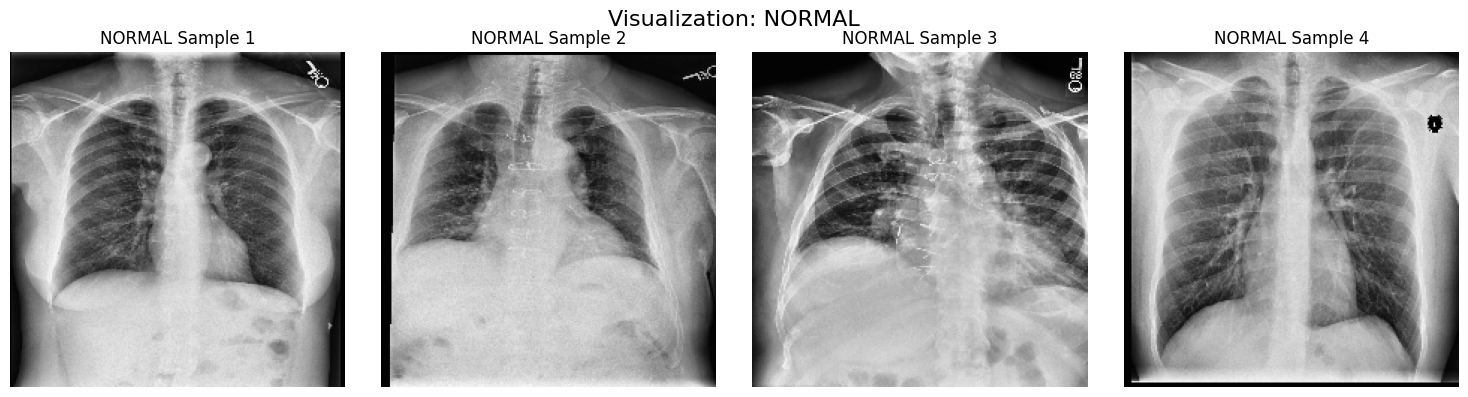

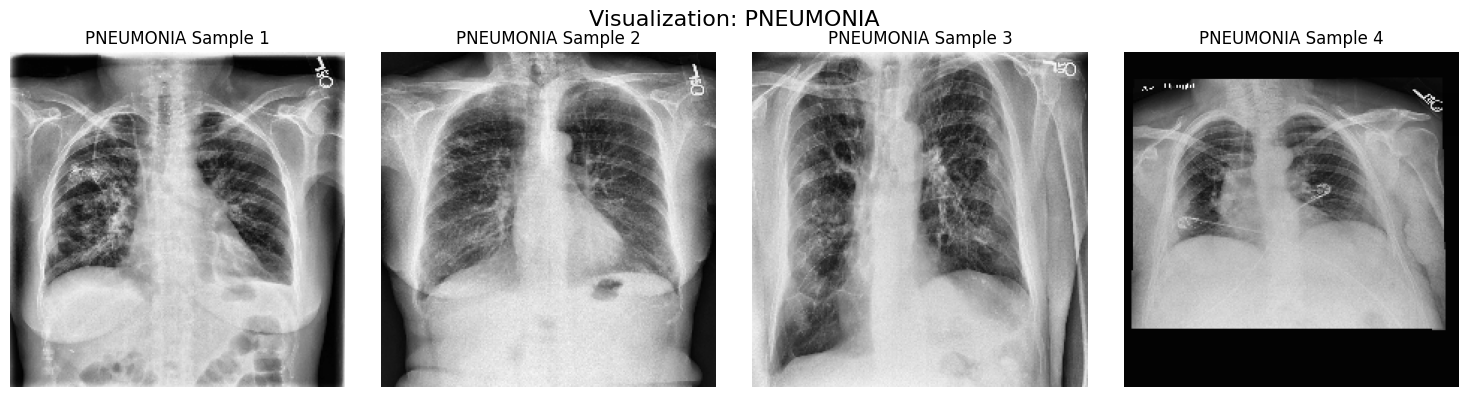

In [9]:
%matplotlib inline
def visualize_samples(df: pd.DataFrame, cls_idx: int = 1, n: int = 4) -> None:
    """지정 클래스(0=NORMAL, 1=PNEUMONIA) 샘플 n장을 격자로 시각화한다."""
    cls_name = CLASS_NAMES[cls_idx]
    subset = df[df[TARGET_COL] == cls_idx]["local_path"].tolist()[:n]

    ncol = min(4, len(subset))
    nrow = (len(subset) + ncol - 1) // ncol     # 실제 장수에 맞춰 격자 계산
    plt.figure(figsize=(15, 4 * nrow))
    for i, path in enumerate(subset):
        img = load_dicom_image(path)      # (H,W,3) uint8
        plt.subplot(nrow, ncol, i + 1)
        plt.imshow(img)
        plt.title(f"{cls_name} Sample {i+1}")
        plt.axis("off")
    plt.suptitle(f"Visualization: {cls_name}", fontsize=16)
    plt.tight_layout()
    plt.show()


visualize_samples(available_df, cls_idx=0, n=4)   # NORMAL 샘플
visualize_samples(available_df, cls_idx=1, n=4)   # PNEUMONIA 샘플

### 셀 7. 이미지 캐싱

`lru_cache`로 한 번 읽은 이미지(전처리 완료본)를 메모리에 저장해 재사용합니다.
CLAHE 연산도 이미지당 한 번만 수행되고 이후 캐시에서 바로 꺼내므로 학습 속도에 부담이 적습니다.

> 캐시에는 **증강 전 원본**이 저장되므로, 증강(`transform`)은 매번 새로 적용되어 캐싱과 충돌하지 않습니다.

In [10]:
from functools import lru_cache

@lru_cache(maxsize=2000)
def _load_cached(path):
    """전처리 완료 이미지를 메모리에 캐싱 (에폭마다 재로딩 방지)."""
    return load_dicom_image(path)

### 셀 8. Dataset · 증강 · 환자 단위 분할 

- **Dataset** (`MIMICCXRDataset`) — 표의 한 행을 `(이미지 텐서, 라벨)`로 변환
- **증강(학습용만)** — `RandomResizedCrop` · 좌우반전 · ±12° 회전 · `ColorJitter`로 과적합 완화
- **검증용** — 증강 없이 원본 그대로(공정한 채점)
- 마지막에 **ImageNet 통계로 표준화**
- **환자(subject_id) 단위 8:2 분할** (`GroupShuffleSplit`)

> 같은 환자 사진이 학습·검증에 섞이면 **데이터 누수**가 생기므로 환자별로 통째 분리합니다.
> CLAHE(고정 전처리)와 `ColorJitter`(랜덤 증강)는 목적이 다릅니다. CLAHE는 *모든* 이미지의 기본 대비를 균일하게 끌어올리고,
> ColorJitter는 *학습 시* 밝기·대비를 무작위로 흔들어 다양성을 줍니다. 둘은 상호 보완적입니다.

In [11]:
class MIMICCXRDataset(Dataset):
    """DataFrame 한 행을 (이미지 텐서, 라벨) 쌍으로 매핑하는 커스텀 Dataset.

    CrossEntropyLoss를 쓰므로 라벨은 long(정수 클래스)로 반환한다.
    """
    def __init__(self, df, transform=None, target_col=TARGET_COL, path_col="local_path"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_col = target_col
        self.path_col = path_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = _load_cached(row[self.path_col])   # 캐시에서 (또는 최초 1회 로딩)
        label = torch.tensor(int(row[self.target_col]), dtype=torch.long)
        if self.transform is not None:
            image = self.transform(image)
        return image, label


# ── ImageNet 사전학습 통계 (전이학습 정규화용) ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 학습용: 데이터 증강(좌우 반전, 회전)으로 과적합을 완화
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),                              # 크롭 여유 확보
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),   # 위치/스케일 다양성
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(12),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),      # 촬영 밝기/대비 편차 대응
    transforms.ToTensor(),                                       # 0~255 -> 0~1, HWC -> CHW
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
# 검증용: 증강 없이 결정론적으로 전처리
#   load_dicom_image가 이미 IMG_SIZE로 리사이즈하므로 Resize 불필요
eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 환자(subject_id) 단위로 8:2 분리 → train/val 데이터 누수 방지
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(gss.split(
    available_df, available_df[TARGET_COL], groups=available_df["subject_id"]
))
train_df = available_df.iloc[train_idx].reset_index(drop=True)
val_df   = available_df.iloc[val_idx].reset_index(drop=True)
print(f"학습용: {len(train_df)} | 검증용: {len(val_df)}")

train_ds = MIMICCXRDataset(train_df, train_transform)
val_ds   = MIMICCXRDataset(val_df,   eval_transform)

# 검증은 shuffle=False 필수: 셀 13의 오답 분석이 val_df와의 인덱스 대응에 의존
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

학습용: 1118 | 검증용: 282


### 셀 9. 모델 — DenseNet121 전이학습 (Feature Extraction)

수백만 장의 ImageNet으로 학습된 **DenseNet121**을 빌려옵니다(CheXNet 등 흉부 X-ray 표준 백본).

**전이학습 방식 두 가지**

| 방식 | 백본 | 학습 대상 | 학습률 | 적합한 상황 |
|---|---|---|---|---|
| **Feature Extraction** | 완전 동결 (`eval` 고정) | classifier head만 (~2K개) | `HEAD_LR=1e-3` | 데이터 소량 (지금: 1,400장) |
| Fine-tuning | 함께 갱신 | 전체 (~7M개) | `FINE_TUNE_LR=1e-4` | 데이터 충분 |

이 노트북은 **순수 feature extraction**(`FREEZE_BACKBONE=True`)을 기본으로 씁니다.

- `Dropout(0.4)` — 과적합 방지
- `CrossEntropyLoss(label_smoothing=0.05)` — 소량 데이터 과신 완화
- `Adam` + `weight_decay=1e-4` — L2 정규화


In [12]:
# ── 전이학습 방식 선택 ──
#   True  → 순수 feature extraction: 백본 완전 동결, classifier head만 학습
#   False → 전체 미세조정(fine-tuning): 데이터가 충분할 때
FREEZE_BACKBONE = True

# ── 방식별 학습률 ──
#   head는 무작위 초기화 상태라 크게 움직여야 빨리 수렴한다.
#   반면 fine-tuning의 백본은 이미 좋은 값을 가지므로 작게 건드려야 한다.
HEAD_LR      = 1e-3   # feature extraction (head만 학습)
FINE_TUNE_LR = 1e-4   # 전체 미세조정


def freeze_backbone_bn(model: nn.Module) -> None:
    """백본의 BatchNorm 레이어를 eval 모드로 고정한다.

    requires_grad=False는 '가중치 업데이트'만 막을 뿐,
    BN의 running_mean/running_var는 train() 모드에서 배치마다 계속 갱신된다.
    이러면 백본이 완전히 고정된 게 아니므로, 순수 feature extraction을 위해
    BN 레이어만 eval 모드로 강제한다. (매 에폭 train() 호출 후 다시 적용해야 함)
    """
    for m in model.features.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()


def create_densenet121_model(num_classes: int = 2,
                             freeze_backbone: bool = True) -> nn.Module:
    """DenseNet121 전이학습 모델을 생성한다.

    DenseNet121은 흉부 X-ray 분류(CheXNet 등)에서 널리 쓰이는 표준 백본으로,
    같은 데이터에서 ResNet18보다 폐렴 검출 성능이 더 좋은 편이다.

    freeze_backbone=True  → 순수 feature extraction
                            백본(features) 전체를 동결하고 classifier head만 학습.
    freeze_backbone=False → 전체 미세조정 (데이터 충분할 때)
    """
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    if freeze_backbone:
        # 백본(features) 전체 동결 — denseblock4도 열지 않는다 (순수 feature extraction)
        for p in model.features.parameters():
            p.requires_grad = False

    # 분류 head 교체: Dropout(0.4) + Linear(→ num_classes)
    #   DenseNet은 마지막 분류층 이름이 fc가 아니라 classifier이다.
    #   in_features(1024)를 하드코딩하지 않고 모델에서 직접 읽어온다.
    #   새로 만든 head는 항상 requires_grad=True (학습 대상)
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier.in_features, num_classes),
    )
    return model


model = create_densenet121_model(num_classes=2,
                                 freeze_backbone=FREEZE_BACKBONE).to(device)
if FREEZE_BACKBONE:
    freeze_backbone_bn(model)   # BN running stats도 고정

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)  # 소량 데이터 과신 완화

# requires_grad=True인 파라미터만 optimizer에 전달 (freeze 시 head만 들어감)
LR_USED = HEAD_LR if FREEZE_BACKBONE else FINE_TUNE_LR
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_USED,
    weight_decay=1e-4,   # L2 정규화로 과적합 완화
)

# ── 학습 대상 파라미터 규모 요약 ──
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
mode = "순수 feature extraction (head만 학습)" if FREEZE_BACKBONE else "전체 미세조정"
print(f"방식: {mode}")
print(f"학습 대상 파라미터: {n_train:,} / {n_total:,}개 "
      f"({n_train / n_total * 100:.2f}%)")
print(f"학습률: {LR_USED}")

# 검증: freeze 모드인데 백본 파라미터가 열려 있으면 경고
if FREEZE_BACKBONE:
    leaked = [n for n, p in model.named_parameters()
              if p.requires_grad and n.startswith("features.")]
    print(f"백본 중 학습 대상: {len(leaked)}개 (0이어야 정상)")

print(model.classifier)

방식: 순수 feature extraction (head만 학습)
학습 대상 파라미터: 2,050 / 6,955,906개 (0.03%)
학습률: 0.001
백본 중 학습 대상: 0개 (0이어야 정상)
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1024, out_features=2, bias=True)
)


### 셀 10. 학습 직전 최종 점검 

시간을 쏟기 전에 데이터 상태를 마지막으로 확인합니다.
1. 실제 샘플 수·클래스 분포
2. **정규화 적용 여부**(배치 값 범위에 음수가 있으면 표준화 정상)
3. **같은 라벨 이미지들의 평균 픽셀이 제각각인지**(다 같으면 로딩 오류)
4. 라벨-이미지 육안 확인 (`SHOW_LABEL_CHECK=True`로 켜기)

In [13]:
# ============ 진단 셀: 학습 전에 데이터 상태를 최종 점검 ============
SHOW_LABEL_CHECK = False   # True면 [4] 라벨-이미지 육안 확인까지 수행

print("=" * 50)
print("[1] 실제 사용된 샘플 수 / 클래스 분포")
print(f"  train_df: {len(train_df)} | val_df: {len(val_df)}")
print(f"  train 양성 비율: {train_df[TARGET_COL].mean():.3f}")
print(f"  val   양성 비율: {val_df[TARGET_COL].mean():.3f}")
print(f"  train 클래스 수: {train_df[TARGET_COL].value_counts().to_dict()}")
print(f"  val   클래스 수: {val_df[TARGET_COL].value_counts().to_dict()}")

print("=" * 50)
print("[2] Normalize 실제 적용 여부 (배치 통계로 확인)")
_xb, _yb = next(iter(train_loader))
print(f"  배치 shape : {tuple(_xb.shape)}")
print(f"  값 범위    : [{_xb.min():.2f}, {_xb.max():.2f}]")   # 정규화되면 음수도 나옴
print(f"  평균/표준편차: {_xb.mean():.3f} / {_xb.std():.3f}")
print(f"  배치 라벨   : {_yb.tolist()}")

print("=" * 50)
print("[3] 같은 라벨 이미지가 실제로 서로 다른지 (픽셀 다양성 확인)")
# 평균 픽셀값이 제각각이어야 정상. 다 똑같으면 이미지 로딩에 문제가 있는 것.
for cls in [0, 1]:
    paths = available_df[available_df[TARGET_COL] == cls]["local_path"].tolist()[:3]
    means = [f"{load_dicom_image(p).mean():.1f}" for p in paths]
    print(f"  클래스 {cls}({CLASS_NAMES[cls]}) 앞 3장 평균픽셀: {means}")

if SHOW_LABEL_CHECK:
    print("=" * 50)
    print("[4] 라벨-이미지 매칭 육안 확인")
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i in range(8):
        row = train_df.iloc[i]
        img = load_dicom_image(row["local_path"])
        ax = axes[i // 4][i % 4]
        ax.imshow(img)
        ax.set_title(f"label={row[TARGET_COL]} ({CLASS_NAMES[row[TARGET_COL]]})")
        ax.axis("off")
    plt.tight_layout(); plt.show()

[1] 실제 사용된 샘플 수 / 클래스 분포
  train_df: 1118 | val_df: 282
  train 양성 비율: 0.500
  val   양성 비율: 0.500
  train 클래스 수: {0: 559, 1: 559}
  val   클래스 수: {0: 141, 1: 141}
[2] Normalize 실제 적용 여부 (배치 통계로 확인)
  배치 shape : (32, 3, 224, 224)
  값 범위    : [-2.12, 2.64]
  평균/표준편차: 0.403 / 1.163
  배치 라벨   : [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]
[3] 같은 라벨 이미지가 실제로 서로 다른지 (픽셀 다양성 확인)
  클래스 0(NORMAL) 앞 3장 평균픽셀: ['142.9', '145.0', '142.5']
  클래스 1(PNEUMONIA) 앞 3장 평균픽셀: ['145.1', '148.0', '152.1']


### 셀 11. 학습 루프

`run_epoch()`가 **예측 → 채점(loss) → 역전파 → 수정**을 반복합니다.
매 에폭마다 학습·검증 성적(loss, accuracy, **AUROC**)을 재고,
**검증 AUROC 최고 기록** 갱신 시 그 모델을 `best_model.pt`로 저장합니다.
`CosineAnnealingLR`은 학습이 진행될수록 학습률을 부드럽게 낮춰 마무리 수렴을 돕습니다.

In [ ]:
def run_epoch(loader, model, criterion, optimizer=None, is_training=True):
    """학습/검증을 한 함수로 처리하고 (평균 loss, accuracy, AUROC)를 반환한다.

    optimizer는 is_training=True 일 때만 필요하다.
    """
    if is_training and optimizer is None:
        raise ValueError("학습 모드에서는 optimizer가 필요합니다.")

    model.train(is_training)                        # train/eval 모드 전환
    # feature extraction 모드면 백본 BN을 다시 eval로 고정
    #   (model.train()이 모든 하위 모듈을 train으로 되돌리므로 매번 재적용 필요)
    if is_training and FREEZE_BACKBONE:
        freeze_backbone_bn(model)

    total_loss, correct, total = 0.0, 0, 0
    probs_all, y_all = [], []

    # 학습일 때만 gradient 추적 (검증 시 메모리/연산 절약)
    with torch.set_grad_enabled(is_training):
        for x, y in tqdm(loader, leave=False):
            x, y = x.to(device), y.to(device)

            if is_training:
                optimizer.zero_grad()               # 1) 이전 gradient 초기화

            logits = model(x)                       # 2) forward
            loss = criterion(logits, y)

            if is_training:
                loss.backward()                     # 3) backward
                optimizer.step()                    # 4) 파라미터 업데이트

            # 배치 크기로 가중해 누적 (마지막 배치가 작아도 정확히 평균)
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
            # AUROC용 폐렴 확률 수집
            probs_all.append(torch.softmax(logits, 1)[:, 1].detach().cpu())
            y_all.append(y.detach().cpu())

    probs = torch.cat(probs_all).numpy()
    ys = torch.cat(y_all).numpy()
    auc = roc_auc_score(ys, probs) if len(np.unique(ys)) > 1 else float("nan")
    return total_loss / max(total, 1), correct / max(total, 1), auc


# ── CosineAnnealingLR: 워밍업 없이 첫 에폭부터 lr이 최고치라 바로 학습이 걸리고,
#    에폭이 진행될수록 부드럽게 낮아져 짧은 학습 예산에서도 마무리 수렴이 좋다.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_auc = -1.0
print("학습 시작\n")
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc, train_auc = run_epoch(
        train_loader, model, criterion, optimizer, is_training=True)
    val_loss, val_acc, val_auc = run_epoch(
        val_loader, model, criterion, is_training=False)
    scheduler.step()                                # 에폭 단위로 lr 갱신

    # 목표 지표인 검증 AUROC가 갱신되면 체크포인트 저장
    flag = ""
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_model.pt")
        flag = "  * best"

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss={train_loss:.4f} acc={train_acc:.3f} auc={train_auc:.3f} | "
          f"val_loss={val_loss:.4f} acc={val_acc:.3f} auc={val_auc:.3f}{flag}")

print(f"\n최고 검증 AUROC = {best_auc:.4f} -> best_model.pt 저장")

학습 시작



  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

Epoch 01/5 | train_loss=0.7012 acc=0.572 auc=0.605 | val_loss=0.6275 acc=0.645 auc=0.785  * best


  0%|          | 0/35 [00:00<?, ?it/s]

### 셀 12. 평가

저장된 최고 모델로 검증셋을 채점합니다.
- **혼동 행렬** — 무엇을 맞히고 틀렸는지 2×2로
- **Classification Report** — 정밀도·재현율·F1
- **ROC-AUC & ROC 곡선** — 정상/폐렴 구분 능력(0.5=찍기, 1.0=완벽)

> 회색 점선은 무작위 분류 기준선. 곡선이 왼쪽 위로 붙을수록 좋습니다.

In [ ]:
@torch.no_grad()
def evaluate_model(loader, model):
    """검증셋 전체에 대해 (실제 라벨, 예측 라벨, 폐렴 확률)을 반환한다."""
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[:, 1]   # 클래스 1(폐렴)일 확률
        preds = logits.argmax(dim=1)
        all_labels.extend(y.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


# best 체크포인트 로드 후 검증셋 평가
# weights_only=True: state_dict만 안전하게 로드 (최신 PyTorch 권장 방식)
model.load_state_dict(torch.load("best_model.pt", weights_only=True))
y_true, y_pred, y_prob = evaluate_model(val_loader, model)

print("[Confusion Matrix]  (행=실제, 열=예측)")
print(confusion_matrix(y_true, y_pred))
print("\n[Classification Report]")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ROC-AUC는 한 클래스만 있으면 계산 불가 → 예외 처리
try:
    auroc = roc_auc_score(y_true, y_prob)
except ValueError:
    auroc = float("nan")
print(f"ROC-AUC : {auroc:.4f}")
print(f"F1      : {f1_score(y_true, y_pred, zero_division=0):.4f}")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")

# ROC curve 그리기
plt.figure(figsize=(5, 5))
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.plot(fpr, tpr, label=f"AUROC={auroc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")   # 무작위 분류 기준선
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC"); plt.legend()
plt.show()

### 셀 13. 오답 분석

오답을 **확신하며 틀린 순**으로 정렬해 CSV로 저장합니다.
- **FP**(정상→폐렴): 불필요한 추가 검사 유발
- **FN**(폐렴→정상): **폐렴을 놓침 → 임상적으로 가장 위험**

> 강하게 확신했는데 틀린 사례에는 배울 점(어려운 케이스, 라벨 오류 등)이 있습니다.
> `val_df`와 `y_pred`의 인덱스 대응은 `val_loader`의 `shuffle=False`에 의존합니다.

In [ ]:
# 예측이 틀린 인덱스 추출
wrong_idx = np.where(y_pred != y_true)[0]
# 확신하며 틀린 순으로 정렬 (|prob - 0.5|가 클수록 확신이 강한 오답)
wrong_idx = sorted(wrong_idx, key=lambda i: abs(y_prob[i] - 0.5), reverse=True)

fp = int(((y_pred == 1) & (y_true == 0)).sum())   # False Positive: 정상 -> 폐렴
fn = int(((y_pred == 0) & (y_true == 1)).sum())   # False Negative: 폐렴 놓침
print(f"오분류: {len(wrong_idx)} / {len(y_true)} 건")
print(f"  False Positive(정상->폐렴): {fp}")
print(f"  False Negative(폐렴 놓침) : {fn}  <- 임상적으로 더 위험")

# 오답 상세 목록을 DataFrame으로 정리
#   file_key는 셀 2에서 미리 만들어 둔 컬럼을 그대로 사용 (basename 재계산 불필요)
wrong_df = pd.DataFrame({
    "subject_id": val_df.iloc[wrong_idx]["subject_id"].values,
    "study_id":   val_df.iloc[wrong_idx]["study_id"].values,
    "file_name":  val_df.iloc[wrong_idx]["file_key"].values,
    "true":       y_true[wrong_idx],
    "prob":       np.round(y_prob[wrong_idx], 4),
    "pred":       y_pred[wrong_idx],
    "error_type": np.where(y_pred[wrong_idx] == 1, "FP(정상->폐렴)", "FN(폐렴놓침)"),
}).sort_values("prob", ascending=False).reset_index(drop=True)

# utf-8-sig로 저장 → Excel에서 한글 깨짐 방지
wrong_df.to_csv("val_wrong_predictions.csv", index=False, encoding="utf-8-sig")
print(f"\n오답 목록 저장: val_wrong_predictions.csv ({len(wrong_df)} 건)")
wrong_df.head(10)

### 셀 14. Grad-CAM — 판단 근거 시각화

**Grad-CAM**은 모델이 주목한 부위를 히트맵으로 색칠합니다.
`GradCAM` 클래스는 DenseNet의 in-place ReLU 문제를 피하려 hook 없이 특징맵을 직접 계산합니다.
이 셀에서는 **폐렴을 가장 확신하며 맞힌 샘플**로 [원본 | 히트맵] 을 나란히 표시합니다.

In [ ]:
class GradCAM:
    """DenseNet의 in-place ReLU 문제를 피하기 위해 features를 직접 계산해
    Grad-CAM 히트맵을 만든다. (forward/backward hook 미사용)

    hook 대신 model.features 출력을 직접 잡으므로, 항상 마지막 conv 블록
    (denseblock4 + norm5)의 특징맵을 사용하게 된다.
    """
    def __init__(self, model):
        self.model = model

    def __call__(self, input_tensor, class_idx=None):
        """input:(1,3,H,W) -> (cam[H,W] 0~1, 예측 클래스, 예측 확률)."""
        self.model.eval()

        # feature extraction으로 백본을 동결하면 features의 파라미터가 모두
        # requires_grad=False라, 입력도 grad를 요구하지 않으면 출력 feats가
        # 그래프에 연결되지 않아 retain_grad()가 실패한다.
        # → 입력 텐서에 requires_grad를 켜서 backbone을 통과하는 그래프를 만든다.
        # enable_grad: 호출부가 torch.no_grad() 안이어도 안전하게 동작하도록 보장.
        with torch.enable_grad():
            x = input_tensor.clone().detach().requires_grad_(True)

            # 1) 마지막 conv 특징맵을 직접 계산 (inplace relu를 타지 않음)
            feats = self.model.features(x)          # (1, C, h, w)
            feats.retain_grad()                     # 중간 텐서의 gradient 보존

            # 2) 분류기까지 수동 forward (torchvision DenseNet.forward 재현)
            out = F.relu(feats, inplace=False)      # 비in-place relu
            out = F.adaptive_avg_pool2d(out, (1, 1))
            out = torch.flatten(out, 1)
            logits = self.model.classifier(out)     # (1, 2)

            probs = torch.softmax(logits, dim=1)
            if class_idx is None:
                class_idx = int(probs.argmax(dim=1).item())
            pred_prob = float(probs[0, class_idx].item())

            # 3) 선택 클래스 점수에 대한 gradient 계산 (softmax가 아닌 raw logit)
            self.model.zero_grad()
            logits[0, class_idx].backward()

            # 4) 채널별 gradient 평균을 가중치로 가중합 후 ReLU
            grads = feats.grad                      # (1, C, h, w)
            weights = grads.mean(dim=(2, 3), keepdim=True)
            cam = F.relu((weights * feats).sum(dim=1, keepdim=True))

            # 5) 입력 크기로 업샘플 + 0~1 정규화
            cam = F.interpolate(cam, size=input_tensor.shape[2:],
                                mode="bilinear", align_corners=False)

        cam = cam.squeeze().detach().cpu().numpy()
        cam -= cam.min()
        if cam.max() > 0:
            cam /= cam.max()

        # head의 gradient가 optimizer에 남지 않도록 정리
        self.model.zero_grad(set_to_none=True)
        return cam, class_idx, pred_prob


def show_original_and_overlay(x, cam, title_right=""):
    """x:(3,H,W) 정규화 텐서, cam:(H,W) 0~1 -> [원본 | Grad-CAM 오버레이] 표시."""
    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)
    img = x.cpu().numpy().transpose(1, 2, 0)           # CHW -> HWC
    img = np.clip(img * std + mean, 0, 1)              # 역정규화하여 원본 밝기 복원

    # 히트맵을 컬러맵으로 변환 후 원본 위에 반투명 합성
    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    overlay = np.clip(0.6 * img + 0.4 * heatmap, 0, 1)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(img);     ax[0].set_title("Original"); ax[0].axis("off")
    ax[1].imshow(overlay); ax[1].set_title(title_right); ax[1].axis("off")
    plt.tight_layout()
    plt.show()


def pick_best_sample(gradcam, ds, device, max_scan=None,
                     only_correct=True, target_class=None):
    """검증셋을 훑어 Grad-CAM 시연에 가장 좋은 샘플을 고른다.
    기준: (선택적으로 정답을 맞춘 것 중) 예측 확률이 가장 높은 샘플.
    반환: (best_idx, x, y, cam, pred_idx, pred_prob)"""
    n = len(ds) if max_scan is None else min(max_scan, len(ds))
    best = None  # (prob, idx, x, y, cam, pred_idx)

    for i in range(n):
        x, y = ds[i]
        y = int(y)
        if target_class is not None and y != target_class:
            continue

        cam, pred_idx, pred_prob = gradcam(x.unsqueeze(0).to(device))

        if only_correct and pred_idx != y:
            continue

        if best is None or pred_prob > best[0]:
            best = (pred_prob, i, x, y, cam, pred_idx)

    if best is None:  # 조건을 만족하는 게 없으면 정답 여부 무시하고 재시도
        return pick_best_sample(gradcam, ds, device, max_scan,
                                only_correct=False, target_class=target_class)

    prob, idx, x, y, cam, pred_idx = best
    return idx, x, y, cam, pred_idx, prob


gradcam = GradCAM(model)

# 폐렴(class 1) 중에서 가장 확신하고 맞춘 샘플 자동 선택
best_idx, x, y, cam, pred_idx, pred_prob = pick_best_sample(
    gradcam, val_ds, device,
    max_scan=40,        # 전체 스캔은 느림 (240장 ≈ 70초) → 앞 40장만
    only_correct=True,  # 정답 맞춘 것 중에서만
    target_class=1      # 폐렴만 (0=NORMAL, 1=PNEUMONIA)
)

print(f"선택된 샘플 index: {best_idx} ({CLASS_NAMES[int(y)]})")
show_original_and_overlay(
    x, cam,
    title_right=f"True: {CLASS_NAMES[int(y)]} | "
                f"Pred: {CLASS_NAMES[pred_idx]} ({pred_prob:.2f})"
)

### 셀 15. Grad-CAM — 오답 사례 분석

반대로 **확신했는데 틀린** 사례(최대 2장)에 Grad-CAM을 적용해 실수의 실마리를 찾습니다.

- **라벨 오류** — 모델이 옳고 원본 라벨이 틀린 경우
- **어려운 케이스** — 초기 폐렴, 미세 병변
- **지름길 학습** — 히트맵이 병변이 아닌 장비·글자에 뜨는 경우

> **FN(폐렴 놓침)** 사례를 특히 자세히 봐야 합니다. 임상적으로 가장 위험한 오류이기 때문입니다.

In [ ]:
# 확신하며 틀린 순으로 최대 2장까지 Grad-CAM 시각화
N_WRONG_SHOW = min(2, len(wrong_idx))
for i in range(N_WRONG_SHOW):
    idx = int(wrong_idx[i])
    x, y = val_ds[idx]
    cam, pred_idx, pred_prob = gradcam(x.unsqueeze(0).to(device))
    show_original_and_overlay(
        x, cam,
        title_right=(f"[오답] True: {CLASS_NAMES[int(y)]} | "
                     f"Pred: {CLASS_NAMES[pred_idx]} ({pred_prob:.2f})")
    )

print(f"Grad-CAM 오답 분석 완료 ({N_WRONG_SHOW}건 표시)")